In [4]:
# ============================================================
# CELDA 1 — MODULADOR GMSK (replica fiel de gmsk_mod de GNU Radio)
# ============================================================
# Reproduce exactamente la cadena de gmsk.py::gmsk_mod:
#
#   bits --> chunks_to_symbols_bf([-1,1])  (NRZ: bit 0->-1, bit 1->+1)
#        --> interp_fir_filter_fff(sps, taps)   (pulse shaping gaussiano)
#        --> frequency_modulator_fc(sensitivity)  (integra fase -> exp(j*ph))
#
# donde:
#   ntaps       = 4 * sps
#   sensitivity = (pi/2) / sps
#   taps        = convolve( firdes.gaussian(1, sps, bt, ntaps), ones(sps) )
#
# firdes.gaussian se reimplementa aca EXACTAMENTE como en el fuente de
# GNU Radio (gr-filter/lib/firdes.cc), sin modificar nada del algoritmo.

import numpy as np
from scipy.signal import fftconvolve

def firdes_gaussian(gain, spb, bt, ntaps):
    """Reimplementacion exacta de gr::filter::firdes::gaussian."""
    taps = np.empty(ntaps)
    dt = 1.0 / spb
    s = 1.0 / (np.sqrt(np.log(2.0)) / (2 * np.pi * bt))
    t0 = -0.5 * ntaps
    scale = 0.0
    for i in range(ntaps):
        t0 += 1.0
        ts = s * dt * t0
        taps[i] = np.exp(-0.5 * ts * ts)
        scale += taps[i]
    return taps / scale * gain

def gmsk_mod(bits, samples_per_symbol, bt=0.35):
    """Modulador GMSK equivalente a gmsk.py::gmsk_mod.
    Entrada: array de bits {0,1}. Salida: señal compleja en banda base a
    'samples_per_symbol' muestras por simbolo."""
    sps = int(samples_per_symbol)
    if sps < 2:
        raise ValueError("samples_per_symbol debe ser entero >= 2")

    ntaps = 4 * sps
    sensitivity = (np.pi / 2) / sps

    # NRZ: bit 0 -> -1, bit 1 -> +1  (chunks_to_symbols_bf([-1,1]))
    nrz = np.where(np.asarray(bits) > 0, 1.0, -1.0)

    # taps = gaussiano (*) ventana rectangular de sps muestras
    gaussian = firdes_gaussian(1.0, sps, bt, ntaps)
    sqwave = np.ones(sps)
    taps = np.convolve(gaussian, sqwave)

    # interp_fir_filter_fff(sps, taps): upsample por sps + FIR
    up = np.zeros(len(nrz) * sps)
    up[::sps] = nrz
    shaped = fftconvolve(up, taps)   # equivalente al FIR interpolador

    # frequency_modulator_fc(sensitivity): integra la fase
    phase = np.cumsum(sensitivity * shaped)
    bb = np.exp(1j * phase)

    info = {
        'sps': sps, 'bt': bt, 'ntaps': ntaps,
        'sensitivity': sensitivity,
        'n_bits': len(nrz),
        'n_muestras_bb': len(bb),
        'taps_len': len(taps),
    }
    return bb, info

# --- demostracion de parametros (sin hardware) ---
if __name__ == "__main__" or True:
    _bits_demo = np.random.RandomState(0).randint(0, 2, 20)
    _bb, _info = gmsk_mod(_bits_demo, samples_per_symbol=8, bt=0.35)
    print("=== Parametros del modulador GMSK ===")
    for k, v in _info.items():
        print(f"  {k}: {v}")
    print(f"  envolvente |bb|: min={np.abs(_bb).min():.4f} "
          f"max={np.abs(_bb).max():.4f} (debe ser ~1, constante)")

=== Parametros del modulador GMSK ===
  sps: 8
  bt: 0.35
  ntaps: 32
  sensitivity: 0.19634954084936207
  n_bits: 20
  n_muestras_bb: 198
  taps_len: 39
  envolvente |bb|: min=1.0000 max=1.0000 (debe ser ~1, constante)


In [5]:
# ============================================================
# CELDA 2 - DEMODULADOR GMSK (replica de gmsk_demod de GNU Radio)
# ============================================================
# Reproduce la cadena de gmsk.py::gmsk_demod:
#
#   señal compleja bb --> quadrature_demod_cf(1/sensitivity)   (demod FM)
#                     --> symbol_sync (M&M TED + interpolador MMSE 8-tap)
#                     --> binary_slicer  (>=0 -> 1, si no -> 0)
#
# Parametros calculados igual que gmsk_demod:
#   omega        = sps * (1 + freq_error)
#   gain_mu      = 0.175  (default)
#   gain_omega   = 0.25 * gain_mu^2         (criticamente amortiguado)
#   max_dev      = omega_relative_limit * sps
#   sensitivity  = (pi/2) / sps
#
# El sincronizador de simbolo usa el detector de error de temporizacion de
# Mueller & Muller y el interpolador FIR MMSE de 8 taps con banco de 128
# fases, IGUAL que gmsk_demod (IR_MMSE_8TAP, 128). Los coeficientes MMSE_TAPS
# son los del fuente de GNU Radio (gr-filter interpolator_taps.h), sin
# modificar.

import numpy as np

# --- coeficientes del interpolador MMSE de 8 taps (129 fases x 8) ---
MMSE_TAPS = np.array([
[0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00],
[-1.547000e-04,8.537770e-04,-2.769680e-03,7.892950e-03,9.985340e-01,-5.410540e-03,1.246420e-03,-1.989930e-04],
[-3.094120e-04,1.708880e-03,-5.551340e-03,1.588400e-02,9.968910e-01,-1.072090e-02,2.479420e-03,-3.963910e-04],
[-4.640530e-04,2.564860e-03,-8.343640e-03,2.397140e-02,9.950740e-01,-1.593050e-02,3.698520e-03,-5.921000e-04],
[-6.185440e-04,3.421300e-03,-1.114530e-02,3.215310e-02,9.930820e-01,-2.103890e-02,4.903220e-03,-7.860310e-04],
[-7.728020e-04,4.277730e-03,-1.395480e-02,4.042740e-02,9.909170e-01,-2.604560e-02,6.093050e-03,-9.780930e-04],
[-9.267470e-04,5.133720e-03,-1.677100e-02,4.879210e-02,9.885800e-01,-3.095030e-02,7.267550e-03,-1.168200e-03],
[-1.080300e-03,5.988830e-03,-1.959250e-02,5.724540e-02,9.860710e-01,-3.575250e-02,8.426260e-03,-1.356270e-03],
[-1.233370e-03,6.842610e-03,-2.241780e-02,6.578520e-02,9.833920e-01,-4.045190e-02,9.568760e-03,-1.542210e-03],
[-1.385890e-03,7.694620e-03,-2.524570e-02,7.440950e-02,9.805430e-01,-4.504830e-02,1.069460e-02,-1.725940e-03],
[-1.537770e-03,8.544410e-03,-2.807460e-02,8.311620e-02,9.775260e-01,-4.954120e-02,1.180340e-02,-1.907380e-03],
[-1.688940e-03,9.391540e-03,-3.090330e-02,9.190330e-02,9.743420e-01,-5.393050e-02,1.289470e-02,-2.086450e-03],
[-1.839310e-03,1.023560e-02,-3.373030e-02,1.007690e-01,9.709920e-01,-5.821590e-02,1.396810e-02,-2.263070e-03],
[-1.988800e-03,1.107600e-02,-3.655410e-02,1.097100e-01,9.674770e-01,-6.239720e-02,1.502330e-02,-2.437180e-03],
[-2.137330e-03,1.191250e-02,-3.937350e-02,1.187250e-01,9.637980e-01,-6.647430e-02,1.605990e-02,-2.608680e-03],
[-2.284830e-03,1.274450e-02,-4.218690e-02,1.278120e-01,9.599580e-01,-7.044710e-02,1.707760e-02,-2.777510e-03],
[-2.431210e-03,1.357160e-02,-4.499290e-02,1.369680e-01,9.559560e-01,-7.431540e-02,1.807590e-02,-2.943610e-03],
[-2.576400e-03,1.439340e-02,-4.779000e-02,1.461920e-01,9.517950e-01,-7.807920e-02,1.905450e-02,-3.106890e-03],
[-2.720320e-03,1.520950e-02,-5.057700e-02,1.554800e-01,9.474770e-01,-8.173850e-02,2.001320e-02,-3.267300e-03],
[-2.862890e-03,1.601930e-02,-5.335220e-02,1.648310e-01,9.430010e-01,-8.529330e-02,2.095160e-02,-3.424770e-03],
[-3.004030e-03,1.682250e-02,-5.611420e-02,1.742420e-01,9.383710e-01,-8.874350e-02,2.186950e-02,-3.579230e-03],
[-3.143670e-03,1.761850e-02,-5.886170e-02,1.837110e-01,9.335860e-01,-9.208930e-02,2.276640e-02,-3.730620e-03],
[-3.281740e-03,1.840710e-02,-6.159310e-02,1.932360e-01,9.286500e-01,-9.533070e-02,2.364230e-02,-3.878880e-03],
[-3.418150e-03,1.918770e-02,-6.430690e-02,2.028140e-01,9.235640e-01,-9.846790e-02,2.449670e-02,-4.023970e-03],
[-3.552830e-03,1.995990e-02,-6.700180e-02,2.124430e-01,9.183290e-01,-1.015010e-01,2.532950e-02,-4.165810e-03],
[-3.685700e-03,2.072330e-02,-6.967620e-02,2.221200e-01,9.129470e-01,-1.044300e-01,2.614040e-02,-4.304350e-03],
[-3.816710e-03,2.147740e-02,-7.232860e-02,2.318430e-01,9.074200e-01,-1.072560e-01,2.692930e-02,-4.439550e-03],
[-3.945760e-03,2.222180e-02,-7.495770e-02,2.416090e-01,9.017490e-01,-1.099780e-01,2.769570e-02,-4.571350e-03],
[-4.072790e-03,2.295620e-02,-7.756200e-02,2.514170e-01,8.959360e-01,-1.125970e-01,2.843970e-02,-4.699700e-03],
[-4.197740e-03,2.368010e-02,-8.013990e-02,2.612630e-01,8.899840e-01,-1.151130e-01,2.916090e-02,-4.824560e-03],
[-4.320520e-03,2.439300e-02,-8.269000e-02,2.711440e-01,8.838930e-01,-1.175260e-01,2.985930e-02,-4.945890e-03],
[-4.441070e-03,2.509460e-02,-8.521090e-02,2.810600e-01,8.776660e-01,-1.198370e-01,3.053450e-02,-5.063630e-03],
[-4.559320e-03,2.578440e-02,-8.770110e-02,2.910060e-01,8.713050e-01,-1.220470e-01,3.118660e-02,-5.177760e-03],
[-4.675200e-03,2.646210e-02,-9.015910e-02,3.009800e-01,8.648120e-01,-1.241540e-01,3.181530e-02,-5.288230e-03],
[-4.788660e-03,2.712720e-02,-9.258340e-02,3.109800e-01,8.581890e-01,-1.261610e-01,3.242050e-02,-5.395000e-03],
[-4.899610e-03,2.777940e-02,-9.497270e-02,3.210040e-01,8.514370e-01,-1.280680e-01,3.300210e-02,-5.498040e-03],
[-5.008000e-03,2.841820e-02,-9.732540e-02,3.310480e-01,8.445590e-01,-1.298740e-01,3.356000e-02,-5.597310e-03],
[-5.113760e-03,2.904330e-02,-9.964020e-02,3.411090e-01,8.375570e-01,-1.315810e-01,3.409400e-02,-5.692800e-03],
[-5.216830e-03,2.965430e-02,-1.019150e-01,3.511860e-01,8.304320e-01,-1.331890e-01,3.460420e-02,-5.784460e-03],
[-5.317160e-03,3.025070e-02,-1.041500e-01,3.612760e-01,8.231880e-01,-1.346990e-01,3.509030e-02,-5.872270e-03],
[-5.414670e-03,3.083230e-02,-1.063420e-01,3.713760e-01,8.158260e-01,-1.361110e-01,3.555250e-02,-5.956200e-03],
[-5.509310e-03,3.139870e-02,-1.084900e-01,3.814840e-01,8.083480e-01,-1.374260e-01,3.599050e-02,-6.036240e-03],
[-5.601030e-03,3.194950e-02,-1.105930e-01,3.915960e-01,8.007570e-01,-1.386440e-01,3.640440e-02,-6.112360e-03],
[-5.689760e-03,3.248430e-02,-1.126500e-01,4.017100e-01,7.930550e-01,-1.397670e-01,3.679410e-02,-6.184540e-03],
[-5.775440e-03,3.300270e-02,-1.146590e-01,4.118230e-01,7.852440e-01,-1.407940e-01,3.715960e-02,-6.252770e-03],
[-5.858040e-03,3.350460e-02,-1.166180e-01,4.219340e-01,7.773270e-01,-1.417270e-01,3.750100e-02,-6.317030e-03],
[-5.937490e-03,3.398940e-02,-1.185260e-01,4.320380e-01,7.693050e-01,-1.425660e-01,3.781820e-02,-6.377300e-03],
[-6.013740e-03,3.445680e-02,-1.203820e-01,4.421340e-01,7.611810e-01,-1.433130e-01,3.811110e-02,-6.433580e-03],
[-6.086740e-03,3.490660e-02,-1.221850e-01,4.522180e-01,7.529580e-01,-1.439680e-01,3.838000e-02,-6.485850e-03],
[-6.156440e-03,3.533840e-02,-1.239330e-01,4.622890e-01,7.446370e-01,-1.445310e-01,3.862470e-02,-6.534120e-03],
[-6.222800e-03,3.575190e-02,-1.256240e-01,4.723420e-01,7.362220e-01,-1.450040e-01,3.884540e-02,-6.578360e-03],
[-6.285770e-03,3.614680e-02,-1.272580e-01,4.823770e-01,7.277140e-01,-1.453870e-01,3.904200e-02,-6.618590e-03],
[-6.345300e-03,3.652270e-02,-1.288320e-01,4.923890e-01,7.191160e-01,-1.456820e-01,3.921470e-02,-6.654790e-03],
[-6.401350e-03,3.687950e-02,-1.303470e-01,5.023770e-01,7.104310e-01,-1.458890e-01,3.936360e-02,-6.686980e-03],
[-6.453880e-03,3.721670e-02,-1.318000e-01,5.123370e-01,7.016610e-01,-1.460090e-01,3.948860e-02,-6.715140e-03],
[-6.502850e-03,3.753410e-02,-1.331900e-01,5.222670e-01,6.928080e-01,-1.460430e-01,3.959000e-02,-6.739290e-03],
[-6.548230e-03,3.783150e-02,-1.345150e-01,5.321640e-01,6.838750e-01,-1.459930e-01,3.966780e-02,-6.759430e-03],
[-6.589960e-03,3.810850e-02,-1.357750e-01,5.420250e-01,6.748650e-01,-1.458590e-01,3.972220e-02,-6.775570e-03],
[-6.628020e-03,3.836500e-02,-1.369690e-01,5.518490e-01,6.657790e-01,-1.456410e-01,3.975320e-02,-6.787710e-03],
[-6.662380e-03,3.860060e-02,-1.380940e-01,5.616310e-01,6.566210e-01,-1.453430e-01,3.976100e-02,-6.795880e-03],
[-6.693000e-03,3.881510e-02,-1.391500e-01,5.713700e-01,6.473940e-01,-1.449630e-01,3.974580e-02,-6.800070e-03],
[-6.719850e-03,3.900830e-02,-1.401360e-01,5.810630e-01,6.380990e-01,-1.445030e-01,3.970770e-02,-6.800320e-03],
[-6.742910e-03,3.918000e-02,-1.410500e-01,5.907060e-01,6.287390e-01,-1.439650e-01,3.964690e-02,-6.796620e-03],
[-6.762140e-03,3.932990e-02,-1.418910e-01,6.002980e-01,6.193180e-01,-1.433500e-01,3.956350e-02,-6.789020e-03],
[-6.777510e-03,3.945780e-02,-1.426580e-01,6.098360e-01,6.098360e-01,-1.426580e-01,3.945780e-02,-6.777510e-03],
[-6.789020e-03,3.956350e-02,-1.433500e-01,6.193180e-01,6.002980e-01,-1.418910e-01,3.932990e-02,-6.762140e-03],
[-6.796620e-03,3.964690e-02,-1.439650e-01,6.287390e-01,5.907060e-01,-1.410500e-01,3.918000e-02,-6.742910e-03],
[-6.800320e-03,3.970770e-02,-1.445030e-01,6.380990e-01,5.810630e-01,-1.401360e-01,3.900830e-02,-6.719850e-03],
[-6.800070e-03,3.974580e-02,-1.449630e-01,6.473940e-01,5.713700e-01,-1.391500e-01,3.881510e-02,-6.693000e-03],
[-6.795880e-03,3.976100e-02,-1.453430e-01,6.566210e-01,5.616310e-01,-1.380940e-01,3.860060e-02,-6.662380e-03],
[-6.787710e-03,3.975320e-02,-1.456410e-01,6.657790e-01,5.518490e-01,-1.369690e-01,3.836500e-02,-6.628020e-03],
[-6.775570e-03,3.972220e-02,-1.458590e-01,6.748650e-01,5.420250e-01,-1.357750e-01,3.810850e-02,-6.589960e-03],
[-6.759430e-03,3.966780e-02,-1.459930e-01,6.838750e-01,5.321640e-01,-1.345150e-01,3.783150e-02,-6.548230e-03],
[-6.739290e-03,3.959000e-02,-1.460430e-01,6.928080e-01,5.222670e-01,-1.331900e-01,3.753410e-02,-6.502850e-03],
[-6.715140e-03,3.948860e-02,-1.460090e-01,7.016610e-01,5.123370e-01,-1.318000e-01,3.721670e-02,-6.453880e-03],
[-6.686980e-03,3.936360e-02,-1.458890e-01,7.104310e-01,5.023770e-01,-1.303470e-01,3.687950e-02,-6.401350e-03],
[-6.654790e-03,3.921470e-02,-1.456820e-01,7.191160e-01,4.923890e-01,-1.288320e-01,3.652270e-02,-6.345300e-03],
[-6.618590e-03,3.904200e-02,-1.453870e-01,7.277140e-01,4.823770e-01,-1.272580e-01,3.614680e-02,-6.285770e-03],
[-6.578360e-03,3.884540e-02,-1.450040e-01,7.362220e-01,4.723420e-01,-1.256240e-01,3.575190e-02,-6.222800e-03],
[-6.534120e-03,3.862470e-02,-1.445310e-01,7.446370e-01,4.622890e-01,-1.239330e-01,3.533840e-02,-6.156440e-03],
[-6.485850e-03,3.838000e-02,-1.439680e-01,7.529580e-01,4.522180e-01,-1.221850e-01,3.490660e-02,-6.086740e-03],
[-6.433580e-03,3.811110e-02,-1.433130e-01,7.611810e-01,4.421340e-01,-1.203820e-01,3.445680e-02,-6.013740e-03],
[-6.377300e-03,3.781820e-02,-1.425660e-01,7.693050e-01,4.320380e-01,-1.185260e-01,3.398940e-02,-5.937490e-03],
[-6.317030e-03,3.750100e-02,-1.417270e-01,7.773270e-01,4.219340e-01,-1.166180e-01,3.350460e-02,-5.858040e-03],
[-6.252770e-03,3.715960e-02,-1.407940e-01,7.852440e-01,4.118230e-01,-1.146590e-01,3.300270e-02,-5.775440e-03],
[-6.184540e-03,3.679410e-02,-1.397670e-01,7.930550e-01,4.017100e-01,-1.126500e-01,3.248430e-02,-5.689760e-03],
[-6.112360e-03,3.640440e-02,-1.386440e-01,8.007570e-01,3.915960e-01,-1.105930e-01,3.194950e-02,-5.601030e-03],
[-6.036240e-03,3.599050e-02,-1.374260e-01,8.083480e-01,3.814840e-01,-1.084900e-01,3.139870e-02,-5.509310e-03],
[-5.956200e-03,3.555250e-02,-1.361110e-01,8.158260e-01,3.713760e-01,-1.063420e-01,3.083230e-02,-5.414670e-03],
[-5.872270e-03,3.509030e-02,-1.346990e-01,8.231880e-01,3.612760e-01,-1.041500e-01,3.025070e-02,-5.317160e-03],
[-5.784460e-03,3.460420e-02,-1.331890e-01,8.304320e-01,3.511860e-01,-1.019150e-01,2.965430e-02,-5.216830e-03],
[-5.692800e-03,3.409400e-02,-1.315810e-01,8.375570e-01,3.411090e-01,-9.964020e-02,2.904330e-02,-5.113760e-03],
[-5.597310e-03,3.356000e-02,-1.298740e-01,8.445590e-01,3.310480e-01,-9.732540e-02,2.841820e-02,-5.008000e-03],
[-5.498040e-03,3.300210e-02,-1.280680e-01,8.514370e-01,3.210040e-01,-9.497270e-02,2.777940e-02,-4.899610e-03],
[-5.395000e-03,3.242050e-02,-1.261610e-01,8.581890e-01,3.109800e-01,-9.258340e-02,2.712720e-02,-4.788660e-03],
[-5.288230e-03,3.181530e-02,-1.241540e-01,8.648120e-01,3.009800e-01,-9.015910e-02,2.646210e-02,-4.675200e-03],
[-5.177760e-03,3.118660e-02,-1.220470e-01,8.713050e-01,2.910060e-01,-8.770110e-02,2.578440e-02,-4.559320e-03],
[-5.063630e-03,3.053450e-02,-1.198370e-01,8.776660e-01,2.810600e-01,-8.521090e-02,2.509460e-02,-4.441070e-03],
[-4.945890e-03,2.985930e-02,-1.175260e-01,8.838930e-01,2.711440e-01,-8.269000e-02,2.439300e-02,-4.320520e-03],
[-4.824560e-03,2.916090e-02,-1.151130e-01,8.899840e-01,2.612630e-01,-8.013990e-02,2.368010e-02,-4.197740e-03],
[-4.699700e-03,2.843970e-02,-1.125970e-01,8.959360e-01,2.514170e-01,-7.756200e-02,2.295620e-02,-4.072790e-03],
[-4.571350e-03,2.769570e-02,-1.099780e-01,9.017490e-01,2.416090e-01,-7.495770e-02,2.222180e-02,-3.945760e-03],
[-4.439550e-03,2.692930e-02,-1.072560e-01,9.074200e-01,2.318430e-01,-7.232860e-02,2.147740e-02,-3.816710e-03],
[-4.304350e-03,2.614040e-02,-1.044300e-01,9.129470e-01,2.221200e-01,-6.967620e-02,2.072330e-02,-3.685700e-03],
[-4.165810e-03,2.532950e-02,-1.015010e-01,9.183290e-01,2.124430e-01,-6.700180e-02,1.995990e-02,-3.552830e-03],
[-4.023970e-03,2.449670e-02,-9.846790e-02,9.235640e-01,2.028140e-01,-6.430690e-02,1.918770e-02,-3.418150e-03],
[-3.878880e-03,2.364230e-02,-9.533070e-02,9.286500e-01,1.932360e-01,-6.159310e-02,1.840710e-02,-3.281740e-03],
[-3.730620e-03,2.276640e-02,-9.208930e-02,9.335860e-01,1.837110e-01,-5.886170e-02,1.761850e-02,-3.143670e-03],
[-3.579230e-03,2.186950e-02,-8.874350e-02,9.383710e-01,1.742420e-01,-5.611420e-02,1.682250e-02,-3.004030e-03],
[-3.424770e-03,2.095160e-02,-8.529330e-02,9.430010e-01,1.648310e-01,-5.335220e-02,1.601930e-02,-2.862890e-03],
[-3.267300e-03,2.001320e-02,-8.173850e-02,9.474770e-01,1.554800e-01,-5.057700e-02,1.520950e-02,-2.720320e-03],
[-3.106890e-03,1.905450e-02,-7.807920e-02,9.517950e-01,1.461920e-01,-4.779000e-02,1.439340e-02,-2.576400e-03],
[-2.943610e-03,1.807590e-02,-7.431540e-02,9.559560e-01,1.369680e-01,-4.499290e-02,1.357160e-02,-2.431210e-03],
[-2.777510e-03,1.707760e-02,-7.044710e-02,9.599580e-01,1.278120e-01,-4.218690e-02,1.274450e-02,-2.284830e-03],
[-2.608680e-03,1.605990e-02,-6.647430e-02,9.637980e-01,1.187250e-01,-3.937350e-02,1.191250e-02,-2.137330e-03],
[-2.437180e-03,1.502330e-02,-6.239720e-02,9.674770e-01,1.097100e-01,-3.655410e-02,1.107600e-02,-1.988800e-03],
[-2.263070e-03,1.396810e-02,-5.821590e-02,9.709920e-01,1.007690e-01,-3.373030e-02,1.023560e-02,-1.839310e-03],
[-2.086450e-03,1.289470e-02,-5.393050e-02,9.743420e-01,9.190330e-02,-3.090330e-02,9.391540e-03,-1.688940e-03],
[-1.907380e-03,1.180340e-02,-4.954120e-02,9.775260e-01,8.311620e-02,-2.807460e-02,8.544410e-03,-1.537770e-03],
[-1.725940e-03,1.069460e-02,-4.504830e-02,9.805430e-01,7.440950e-02,-2.524570e-02,7.694620e-03,-1.385890e-03],
[-1.542210e-03,9.568760e-03,-4.045190e-02,9.833920e-01,6.578520e-02,-2.241780e-02,6.842610e-03,-1.233370e-03],
[-1.356270e-03,8.426260e-03,-3.575250e-02,9.860710e-01,5.724540e-02,-1.959250e-02,5.988830e-03,-1.080300e-03],
[-1.168200e-03,7.267550e-03,-3.095030e-02,9.885800e-01,4.879210e-02,-1.677100e-02,5.133720e-03,-9.267470e-04],
[-9.780930e-04,6.093050e-03,-2.604560e-02,9.909170e-01,4.042740e-02,-1.395480e-02,4.277730e-03,-7.728020e-04],
[-7.860310e-04,4.903220e-03,-2.103890e-02,9.930820e-01,3.215310e-02,-1.114530e-02,3.421300e-03,-6.185440e-04],
[-5.921000e-04,3.698520e-03,-1.593050e-02,9.950740e-01,2.397140e-02,-8.343640e-03,2.564860e-03,-4.640530e-04],
[-3.963910e-04,2.479420e-03,-1.072090e-02,9.968910e-01,1.588400e-02,-5.551340e-03,1.708880e-03,-3.094120e-04],
[-1.989930e-04,1.246420e-03,-5.410540e-03,9.985340e-01,7.892950e-03,-2.769680e-03,8.537770e-04,-1.547000e-04],
[0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00]
])

def _mmse_interp(buf, i, mu):
    """Interpola buf en la posicion i+mu con el banco MMSE de 8 taps,
    igual que mmse_fir_interpolator_ff de GNU Radio."""
    imu = int(round(mu * 128))
    if imu > 128:
        imu = 128; i += 1
    if i < 3 or i + 4 >= len(buf):
        return buf[i] if 0 <= i < len(buf) else 0.0
    t = MMSE_TAPS[imu]
    # los 8 taps se aplican a buf[i-3 .. i+4]
    return float(np.dot(t, buf[i-3:i+5]))

def quadrature_demod(bb, gain):
    """quadrature_demod_cf: gain * arg( x[n] * conj(x[n-1]) )."""
    return gain * np.angle(bb[1:] * np.conj(bb[:-1]))

def _slice(x):
    return 1.0 if x >= 0.0 else -1.0

def clock_recovery_mm(x, omega, gain_omega, mu, gain_mu, omega_rel):
    """Recuperacion de reloj Mueller&Muller con interpolador MMSE, como el
    nucleo de temporizacion de symbol_sync/clock_recovery_mm de GNU Radio.
    Devuelve los simbolos blandos (float)."""
    omega_mid = omega
    omega_lim = omega_rel * omega
    d_mu = mu
    d_omega = omega
    last = 0.0
    out = []
    i = 3
    n = len(x)
    while i < n - 4:
        s = _mmse_interp(x, i, d_mu)
        out.append(s)
        mm = _slice(last) * s - _slice(s) * last   # error M&M
        last = s
        d_omega = d_omega + gain_omega * mm
        d_omega = omega_mid + np.clip(d_omega - omega_mid, -omega_lim, omega_lim)
        d_mu = d_mu + d_omega + gain_mu * mm
        i += int(np.floor(d_mu))
        d_mu = d_mu - np.floor(d_mu)
    return np.array(out)

def gmsk_demod(bb, samples_per_symbol, gain_mu=0.175,
               omega_relative_limit=0.005, freq_error=0.0):
    """Demodulador GMSK equivalente a gmsk.py::gmsk_demod.
    Entrada: señal compleja en banda base a 'samples_per_symbol' muestras por
    simbolo. Salida: bits {0,1}."""
    sps = samples_per_symbol
    omega = sps * (1.0 + freq_error)
    gain_omega = 0.25 * gain_mu * gain_mu          # criticamente amortiguado
    max_dev = omega_relative_limit * sps
    sensitivity = (np.pi / 2) / sps

    # demod FM
    freq = quadrature_demod(bb, gain=1.0 / sensitivity)
    # recuperacion de reloj M&M (mu inicial 0.5, como el default de gmsk_demod)
    soft = clock_recovery_mm(freq, omega, gain_omega, 0.5, gain_mu,
                             omega_relative_limit)
    # binary_slicer: >=0 -> 1
    bits = (soft >= 0.0).astype(np.uint8)

    info = {
        'sps': sps, 'omega': omega, 'gain_mu': gain_mu,
        'gain_omega': gain_omega, 'max_dev': max_dev,
        'sensitivity': sensitivity,
        'n_muestras_in': len(bb), 'n_simbolos_out': len(bits),
    }
    return bits, soft, freq, info

# --- demostracion de parametros ---
_info_demo = dict(sps=8, omega=8.0, gain_mu=0.175,
                  gain_omega=0.25*0.175**2, max_dev=0.005*8,
                  sensitivity=(np.pi/2)/8)
print("=== Parametros del demodulador GMSK ===")
for k, v in _info_demo.items():
    print(f"  {k}: {v}")
print(f"  interpolador: MMSE 8 taps, banco de 128 fases (IR_MMSE_8TAP)")

=== Parametros del demodulador GMSK ===
  sps: 8
  omega: 8.0
  gain_mu: 0.175
  gain_omega: 0.007656249999999999
  max_dev: 0.04
  sensitivity: 0.19634954084936207
  interpolador: MMSE 8 taps, banco de 128 fases (IR_MMSE_8TAP)


=== Modulacion (gmsk_mod) ===
  sps: 13021
  bt: 0.35
  ntaps: 52084
  sensitivity: 0.0001206356137619919
  n_bits: 128
  n_muestras_bb: 1731791
  taps_len: 65104

Buffer TX: 1731776 muestras (54118 rafagas), fc=10.715012 MHz (offset 15.01 kHz)

Portadora recibida (mediana freq inst): 14.412 kHz (esperado ~+15 kHz)

=== Demodulacion (gmsk_demod) ===
  sps: 20.00128008192524
  omega: 20.00128008192524
  gain_mu: 0.175
  gain_omega: 0.007656249999999999
  max_dev: 0.1000064004096262
  sensitivity: 0.0785347897914991
  n_muestras_in: 8000
  n_simbolos_out: 399

=== Verificacion ===
bits transmitidos: 128, demodulados: 399
mejor alineamiento: offset 65, polaridad normal
errores: 29/128  (BER = 0.2266)


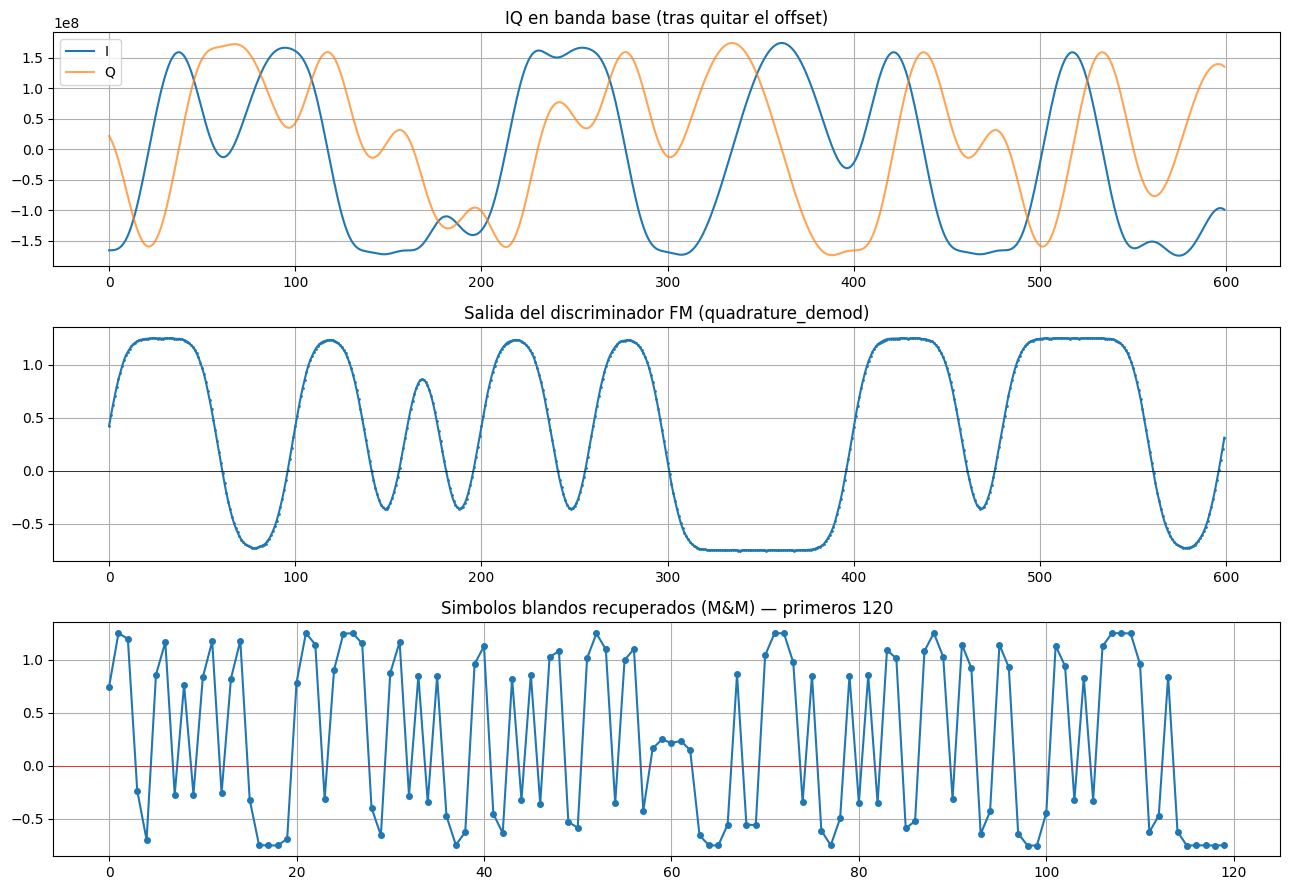

In [6]:
# ============================================================
# CELDA 3 — TEST GMSK POR LOOPBACK (Red Pitaya)
# ============================================================
# Usa gmsk_mod (celda 1) y gmsk_demod (celda 2) sobre el hardware real:
#
#   bits aleatorios --> gmsk_mod --> upconversion a fc --> DAC (loop) -->
#   ADC --> mezcla a banda base --> gmsk_demod --> bits --> comparar
#
# La modulacion se genera con gmsk_mod a SPS_TX = round(FS/BAUD) muestras por
# simbolo (para que la señal compleja quede directamente a la tasa del DAC de
# 125 MHz, con envolvente constante). Se sube a la portadora fc = f_lo + 15kHz
# (offset para no quedar en DC, donde el offset de continua del ADC domina).
# En RX se captura, se mezcla a banda base para quitar ese offset, y se pasa a
# gmsk_demod tal cual.
#
# Requiere ya ejecutadas la CELDA 1 (gmsk_mod, firdes_gaussian) y la CELDA 2
# (gmsk_demod).

import socket, struct
import numpy as np
import matplotlib.pyplot as plt

# ---------------- parametros ----------------
HOST = '10.19.216.50'
PORT = 1003

CMD_READ_ADC = 0x03
CMD_SET_FIFO = 0x04
CMD_SET_CFG  = 0x05
CMD_TX_LOAD  = 0x06
CMD_TX_START = 0x07
CMD_TX_STOP  = 0x08

FS      = 125e6
fs_out  = 125e6 / 651     # ~192012 sps (tasa de salida del RX)
f_lo    = 10.7e6          # LO del receptor
OFFSET  = 15e3            # offset de portadora sobre el LO
BAUD    = 9600.0
BT      = 0.35            # mismo default que gmsk_mod
N_BITS  = 128             # bits aleatorios a transmitir
AMPLITUD = 4000
TX_BURST_SAMPLES = 32

SPS_TX = round(FS / BAUD)   # muestras/simbolo del modulador (a 125 MHz)
SPS_RX = fs_out / BAUD      # muestras/simbolo en RX (~20)

PINC = round(f_lo / FS * (1 << 30))
CFG_VAL_RESET = (PINC << 1) | 0
CFG_VAL_RUN   = (PINC << 1) | 1

# ---------------- comunicacion ----------------
def send_cmd(sock, cmd, payload):
    sock.sendall(struct.pack('B', cmd)); sock.sendall(struct.pack('I', payload))

def read_ack(sock):
    return sock.recv(1)[0] == 0x01

def tx_load_and_start(sock, words):
    send_cmd(sock, CMD_TX_LOAD, len(words))
    sock.sendall(words.astype(np.int32).tobytes()); read_ack(sock)
    send_cmd(sock, CMD_TX_START, 0); read_ack(sock)

def tx_stop(sock):
    send_cmd(sock, CMD_TX_STOP, 0); read_ack(sock)

def read_adc(sock, n_samples):
    n_words = n_samples * 2
    send_cmd(sock, CMD_SET_FIFO, 0); read_ack(sock)
    send_cmd(sock, CMD_SET_FIFO, 1); read_ack(sock)
    send_cmd(sock, CMD_READ_ADC, n_words)
    raw = b''; total = n_words * 4
    while len(raw) < total:
        raw += sock.recv(total - len(raw))
    w = struct.unpack(f'{n_words}i', raw)
    return np.array(w[0::2], float), np.array(w[1::2], float)

# ---------------- 1) generar bits y modular con gmsk_mod ----------------
rng = np.random.RandomState(2024)
bits_tx = rng.randint(0, 2, N_BITS)

bb, mod_info = gmsk_mod(bits_tx, samples_per_symbol=SPS_TX, bt=BT)
print("=== Modulacion (gmsk_mod) ===")
for k, v in mod_info.items():
    print(f"  {k}: {v}")

# ---------------- 2) upconversion a fc y empaquetado para el DAC ----------
# recortar a multiplo de rafaga y ajustar portadora al bin (cierre en loop)
N = (len(bb) // TX_BURST_SAMPLES) * TX_BURST_SAMPLES
bb = bb[:N]
fc = f_lo + OFFSET
cycles = round(N * fc / FS); fc_adj = cycles * FS / N
t = np.arange(N) / FS
rf = np.real(bb * np.exp(1j * 2*np.pi * fc_adj * t))
rf_i16 = (rf / np.max(np.abs(rf)) * AMPLITUD).astype(np.int16)
words_tx = (rf_i16.astype(np.int32) & 0x3FFF)
print(f"\nBuffer TX: {N} muestras ({N//TX_BURST_SAMPLES} rafagas), "
      f"fc={fc_adj/1e6:.6f} MHz (offset {(fc_adj-f_lo)/1e3:.2f} kHz)")

# ---------------- 3) transmitir, capturar, demodular ----------------
sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
sock.connect((HOST, PORT))
tx_load_and_start(sock, words_tx)
send_cmd(sock, CMD_SET_CFG, CFG_VAL_RESET); read_ack(sock)
send_cmd(sock, CMD_SET_CFG, CFG_VAL_RUN);   read_ack(sock)

n_rx = 8000
I_bb, Q_bb = read_adc(sock, n_rx)
tx_stop(sock); sock.close()

iq = I_bb + 1j * Q_bb

# mezclar a banda base (quitar el offset de portadora) antes de gmsk_demod.
# la portadora se estima por la mediana de la frecuencia instantanea (robusta).
nfp = np.arange(len(iq))
f_port = np.median(np.diff(np.unwrap(np.angle(iq))) / (2*np.pi) * fs_out)
iq_bb = iq * np.exp(-1j * 2*np.pi * f_port/fs_out * nfp)
print(f"\nPortadora recibida (mediana freq inst): {f_port/1e3:.3f} kHz "
      f"(esperado ~+{OFFSET/1e3:.0f} kHz)")

# demodular con gmsk_demod
bits_rx, soft, freq, demod_info = gmsk_demod(iq_bb, SPS_RX)
print("\n=== Demodulacion (gmsk_demod) ===")
for k, v in demod_info.items():
    print(f"  {k}: {v}")

# ---------------- 4) verificar BER ----------------
# El TX corre en loop y la captura arranca en un punto aleatorio, asi que la
# secuencia recibida esta rotada respecto de bits_tx. Se busca el mejor
# alineamiento circular (y ambas polaridades) y se mide el BER en la ventana
# donde solapan.
def mejor_alineamiento(rx, tx):
    tx2 = np.concatenate([tx, tx])   # para alineamiento circular
    mejor = None
    for pol, r in [('normal', rx), ('invertida', 1 - rx)]:
        L = min(len(r), len(tx))
        for off in range(len(tx)):
            seg = tx2[off:off+L]
            err = int(np.sum(r[:L] != seg[:L]))
            if mejor is None or err < mejor[0]:
                mejor = (err, L, off, pol)
    return mejor

err, L, off, pol = mejor_alineamiento(np.asarray(bits_rx), bits_tx)
print("\n=== Verificacion ===")
print(f"bits transmitidos: {len(bits_tx)}, demodulados: {len(bits_rx)}")
print(f"mejor alineamiento: offset {off}, polaridad {pol}")
print(f"errores: {err}/{L}  (BER = {err/L:.4f})")
if err == 0:
    print(">> *** BITS RECUPERADOS EXACTOS (BER = 0) ***")

# ---------------- 5) graficas ----------------
fig, axes = plt.subplots(3, 1, figsize=(13, 9))
axes[0].plot(np.real(iq_bb[:600]), label='I'); axes[0].plot(np.imag(iq_bb[:600]), label='Q', alpha=0.7)
axes[0].set_title('IQ en banda base (tras quitar el offset)'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(freq[:600], '.-', ms=2); axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('Salida del discriminador FM (quadrature_demod)'); axes[1].grid(True)
axes[2].plot(soft[:120], 'o-', ms=4); axes[2].axhline(0, color='r', lw=0.5)
axes[2].set_title('Simbolos blandos recuperados (M&M) — primeros 120'); axes[2].grid(True)
plt.tight_layout(); plt.show()